<a href="https://colab.research.google.com/github/vennilakm04/Cognifyz_internship/blob/main/Cognifyz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#level 1
import pandas as pd

# Load dataset
df = pd.read_csv('Dataset .csv')

print("="*65)
print("LEVEL 1 TASK 1: DATA EXPLORATION AND PREPROCESSING")
print("="*65)

# Task 1: Exploration and Preprocessing
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

unrated_count = (df['Aggregate rating'] == 0).sum()
print(f"\nUnrated Restaurants (0.0 rating): {unrated_count} ({unrated_count/len(df)*100:.2f}%)")

print("\n" + "="*65)
print("LEVEL 1 TASK 2: DESCRIPTIVE ANALYSIS")
print("="*65)

# Task 2: Descriptive Analysis
print("Top 5 Cities by Restaurant Count:")
print(df['City'].value_counts().head(5))

# Expand multi-cuisine strings
cuisines_series = df['Cuisines'].dropna().str.split(', ').explode()
print("\nTop 5 Most Common Cuisines:")
print(cuisines_series.value_counts().head(5))

print("\n" + "="*65)
print("LEVEL 1 TASK 3: GEOSPATIAL ANALYSIS")
print("="*65)

# Task 3: Geospatial Correlation
lat_corr = df['Latitude'].corr(df['Aggregate rating'])
lon_corr = df['Longitude'].corr(df['Aggregate rating'])
print(f"Correlation between Latitude and Rating:  {lat_corr:.4f}")
print(f"Correlation between Longitude and Rating: {lon_corr:.4f}")

LEVEL 1 TASK 1: DATA EXPLORATION AND PREPROCESSING
Dataset Shape: 9551 rows, 21 columns

Missing Values:
Cuisines    9
dtype: int64

Unrated Restaurants (0.0 rating): 2148 (22.49%)

LEVEL 1 TASK 2: DESCRIPTIVE ANALYSIS
Top 5 Cities by Restaurant Count:
City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64

Top 5 Most Common Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Name: count, dtype: int64

LEVEL 1 TASK 3: GEOSPATIAL ANALYSIS
Correlation between Latitude and Rating:  0.0005
Correlation between Longitude and Rating: -0.1168


In [ ]:
#level 2
import pandas as pd

# Load dataset
df = pd.read_csv('Dataset .csv')

print("="*65)
print("LEVEL 2 TASK 1: TABLE BOOKING AND ONLINE DELIVERY")
print("="*65)

# Task 1: Table Booking and Online Delivery
tbl_pct = (df['Has Table booking'] == 'Yes').mean() * 100
del_pct = (df['Has Online delivery'] == 'Yes').mean() * 100

print(f"Percentage of restaurants with Table Booking: {tbl_pct:.2f}%")
print(f"Percentage of restaurants with Online Delivery: {del_pct:.2f}%")

avg_rating_tbl = df.groupby('Has Table booking')['Aggregate rating'].mean()
print("\nAverage Rating by Table Booking Availability:")
print(avg_rating_tbl)

delivery_by_price = pd.crosstab(df['Price range'], df['Has Online delivery'], normalize='index') * 100
print("\nOnline Delivery Availability across Price Ranges (%):")
print(delivery_by_price)

print("\n" + "="*65)
print("LEVEL 2 TASK 2: PRICE RANGE ANALYSIS")
print("="*65)

# Task 2: Price Range Analysis
most_common_price = df['Price range'].mode()[0]
avg_rating_by_price = df.groupby('Price range')['Aggregate rating'].mean()

print(f"Most Common Price Range: {most_common_price}")
print("\nAverage Rating by Price Range:")
print(avg_rating_by_price)

highest_price_group = avg_rating_by_price.idxmax()
highest_color = df[df['Price range'] == highest_price_group]['Rating color'].value_counts()
print(f"\nRating Color Distribution for Price Range {highest_price_group}:")
print(highest_color)

print("\n" + "="*65)
print("LEVEL 2 TASK 3: FEATURE ENGINEERING")
print("="*65)

# Task 3: Feature Engineering
# 1. Extract string lengths
df['Restaurant_Name_Length'] = df['Restaurant Name'].apply(lambda x: len(str(x)))
df['Address_Length'] = df['Address'].apply(lambda x: len(str(x)))

# 2. Categorical encoding
df['Has_Table_Booking_Num'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has_Online_Delivery_Num'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

print("Extracted String Length Features (Head):")
print(df[['Restaurant Name', 'Restaurant_Name_Length', 'Address', 'Address_Length']].head())

print("\nEncoded Binary Features Summary:")
print(df[['Has_Table_Booking_Num', 'Has_Online_Delivery_Num']].value_counts())

LEVEL 2 TASK 1: TABLE BOOKING AND ONLINE DELIVERY
Percentage of restaurants with Table Booking: 12.12%
Percentage of restaurants with Online Delivery: 25.66%

Average Rating by Table Booking Availability:
Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64

Online Delivery Availability across Price Ranges (%):
Has Online delivery         No        Yes
Price range                              
1                    84.225923  15.774077
2                    58.689367  41.310633
3                    70.809659  29.190341
4                    90.955631   9.044369

LEVEL 2 TASK 2: PRICE RANGE ANALYSIS
Most Common Price Range: 1

Average Rating by Price Range:
Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64

Rating Color Distribution for Price Range 4:
Rating color
Yellow        200
Green         194
Orange        101
Dark Green     74
White          11
Red             6
Name: count, dtype: int64

L

LEVEL 3 TASK 1: PREDICTIVE MODELING
Predictive Model Evaluation Metrics:
 Linear Regression R² Score: 0.2976
 Linear Regression RMSE:    1.2644
 Random Forest R² Score:     0.9492
 Random Forest RMSE:        0.3400

LEVEL 3 TASK 2: CUSTOMER PREFERENCE ANALYSIS
Top 5 Cuisines by Total Votes (Popularity):
Cuisines
North Indian    595981
Chinese         364351
Italian         329265
Continental     288255
Fast Food       184058
Name: Votes, dtype: int64

Top 5 Cuisines by Highest Average Rating (Min 50 reviews):
Cuisines
Sandwich         4.066038
Steak            3.985484
Sushi            3.973333
Mediterranean    3.948214
Indian           3.918571
Name: Aggregate rating, dtype: float64

LEVEL 3 TASK 3: DATA VISUALIZATION


/tmp/ipykernel_1724/473186395.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_price.index, y=avg_rating_by_price.values, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_1724/473186395.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Has Table booking', y='Aggregate rating', data=df, ax=axes[1, 0], palette='Set2')


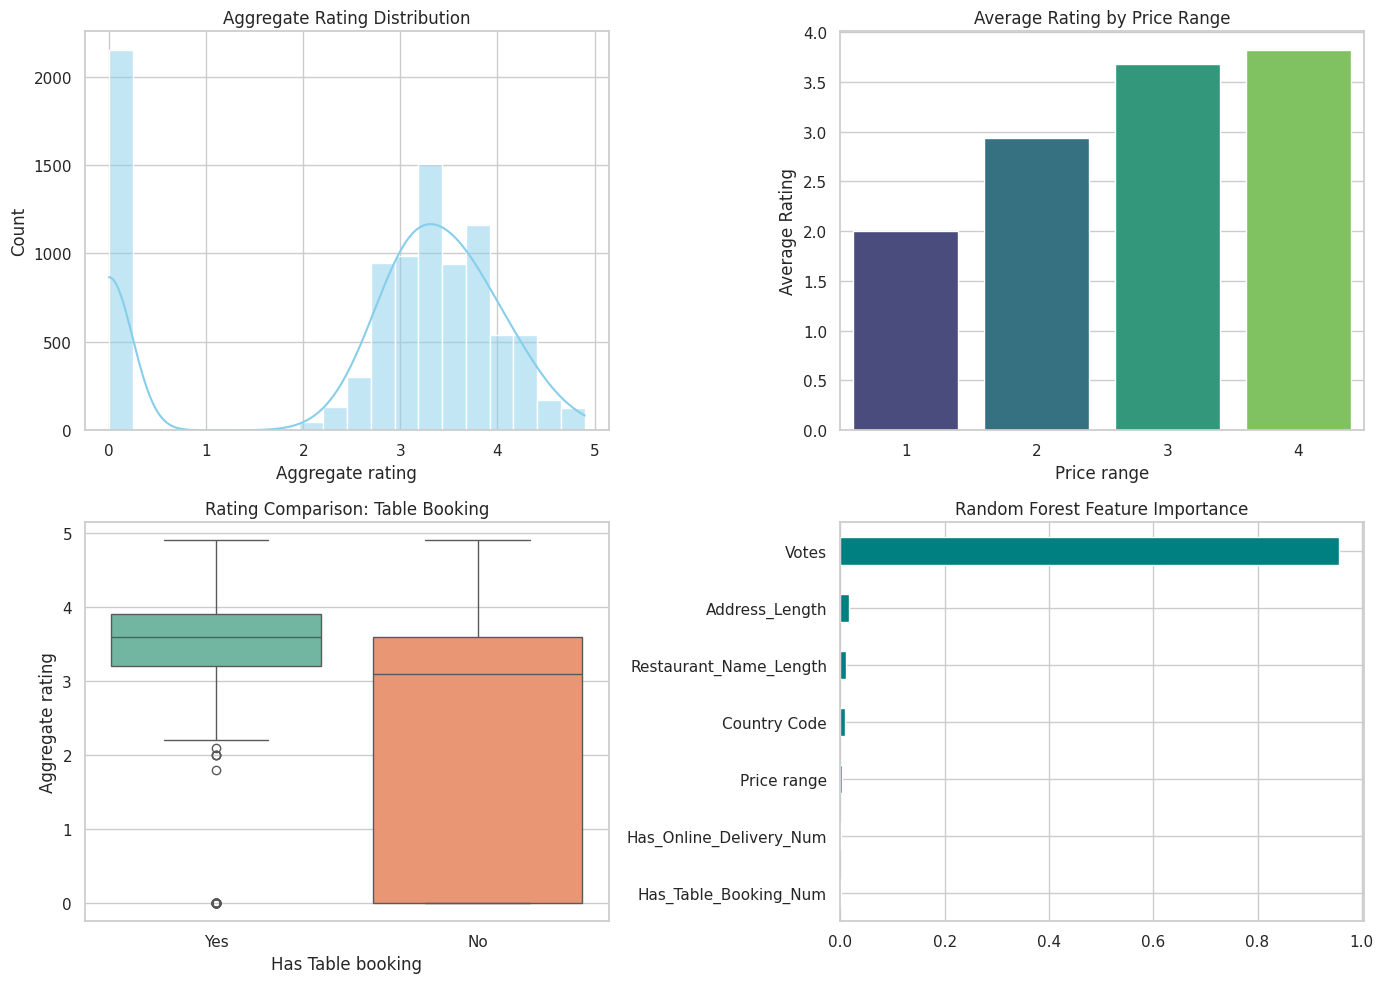


Execution complete! Visualizations saved to 'level_3_visualizations.png'.


In [ ]:
#level 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('Dataset .csv')

# Feature Engineering steps required for Level 3 modeling
df['Restaurant_Name_Length'] = df['Restaurant Name'].apply(lambda x: len(str(x)))
df['Address_Length'] = df['Address'].apply(lambda x: len(str(x)))
df['Has_Table_Booking_Num'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has_Online_Delivery_Num'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

print("="*65)
print("LEVEL 3 TASK 1: PREDICTIVE MODELING")
print("="*65)

# Task 1: Predictive Modeling
features = ['Country Code', 'Price range', 'Votes', 'Has_Table_Booking_Num', 'Has_Online_Delivery_Num', 'Restaurant_Name_Length', 'Address_Length']
X = df[features]
y = df['Aggregate rating']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Random Forest Regressor Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Predictive Model Evaluation Metrics:")
print(f" Linear Regression R² Score: {r2_score(y_test, lr_preds):.4f}")
print(f" Linear Regression RMSE:    {np.sqrt(mean_squared_error(y_test, lr_preds)):.4f}")
print(f" Random Forest R² Score:     {r2_score(y_test, rf_preds):.4f}")
print(f" Random Forest RMSE:        {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")

print("\n" + "="*65)
print("LEVEL 3 TASK 2: CUSTOMER PREFERENCE ANALYSIS")
print("="*65)

# Task 2: Customer Preference Analysis
df_cuisines = df[['Cuisines', 'Aggregate rating', 'Votes']].dropna().copy()
df_cuisines = df_cuisines.assign(Cuisines=df_cuisines['Cuisines'].str.split(', ')).explode('Cuisines')

top_voted = df_cuisines.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False).head(5)
print("Top 5 Cuisines by Total Votes (Popularity):")
print(top_voted)

top_rated = df_cuisines.groupby('Cuisines').filter(lambda x: len(x) >= 50)
top_rated_cuisines = top_rated.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(5)
print("\nTop 5 Cuisines by Highest Average Rating (Min 50 reviews):")
print(top_rated_cuisines)

print("\n" + "="*65)
print("LEVEL 3 TASK 3: DATA VISUALIZATION")
print("="*65)

# Task 3: Data Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rating Distribution
sns.histplot(df['Aggregate rating'], bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Aggregate Rating Distribution')

# 2. Price Range vs Rating
avg_rating_by_price = df.groupby('Price range')['Aggregate rating'].mean()
sns.barplot(x=avg_rating_by_price.index, y=avg_rating_by_price.values, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Average Rating by Price Range')
axes[0, 1].set_ylabel('Average Rating')

# 3. Table Booking vs Rating
sns.boxplot(x='Has Table booking', y='Aggregate rating', data=df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Rating Comparison: Table Booking')

# 4. Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Random Forest Feature Importance')

plt.tight_layout()
plt.savefig('level_3_visualizations.png', dpi=300)
plt.show()

print("\nExecution complete! Visualizations saved to 'level_3_visualizations.png'.")